<a href="https://colab.research.google.com/github/DJCordhose/buch-machine-learning-notebooks/blob/master/kap10-bert-fine-tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BERT sentiment fine tuning mit PyTorch

**hierfür brauchen wir eine GPU**

* https://colab.research.google.com/github/huggingface/notebooks/blob/main/transformers_doc/en/pytorch/training.ipynb
* https://huggingface.co/docs/transformers/training
* https://huggingface.co/docs/datasets/
* https://github.com/huggingface/datasets
* https://huggingface.co/datasets/imdb


## Installation

In [1]:
import sys
IN_COLAB = 'google.colab' in sys.modules
IN_COLAB

False

In [2]:
if IN_COLAB:
    # https://huggingface.co/transformers/installation.html
    # https://huggingface.co/docs/datasets/installation.html
    # PyTorch ist in Colab typischerweise bereits installiert.
    # !pip install -q transformers
    !pip install -q datasets


In [3]:
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
import matplotlib as mpl
mpl.rcParams['figure.figsize'] = (20, 8)
mpl.rcParams['axes.titlesize'] = 24
mpl.rcParams['axes.labelsize'] = 20

figsize_3d = (20, 10)

In [5]:
import os
import torch
torch.__version__


'2.11.0'

In [6]:
torch.manual_seed(42)

# je mehr Bums desto besser
# Standard: Colab/CUDA
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
    os.system("nvidia-smi")
    device = torch.device("cuda")  # NVIDIA/Colab
# Sonderfall: Mac mit Apple Silicon:
elif torch.backends.mps.is_available():
    device = torch.device("mps")   # Apple Silicon GPU
# Fallback: CPU
else:
    device = torch.device("cpu")

print(device)

mps


## Daten holen und vorbereiten

In [7]:
from datasets import load_dataset

raw_datasets = load_dataset("imdb")

In [8]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [9]:
example_idx = 0
raw_datasets["train"]['text'][example_idx]

'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far between, ev

In [10]:
# 0: neg, 1: pos
raw_datasets["train"]['label'][example_idx]

0

In [11]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")

In [12]:
del raw_datasets["unsupervised"]

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True)

tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)

In [13]:
# train_dataset = tokenized_datasets["train"]
# eval_dataset = tokenized_datasets["test"]

## Fine Tuning des vortrainierten Modells

In [14]:
small_size = 1_000
train_dataset = tokenized_datasets["train"].shuffle(seed=42).select(range(small_size))
eval_dataset = tokenized_datasets["test"].shuffle(seed=42).select(range(small_size))

In [15]:
import torch
from transformers import AutoModelForSequenceClassification
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")
model     = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-cased",
    num_labels=2
)

model.to(device)
model


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(28996, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [ ]:
# 1 to 3 minutes per epoch on decent GPU (e.g. V100 1min, T4 3min)
# don't train for too long, model will overfit
# For comparison: On a Mac mini m4 with 32GB RAM
# it took about 19 minutes for 5 epochs.
EPOCHS = 5
# reduce batch size when you encounter OOM error
# note, model has more than 100M parameters
# batch size 8 doable on 16GB
BATCH_SIZE = 8
# don't forget, we are fine tuning, increasing the LR might keep the model from even training
# LR = 3e-5
LR = 1e-5


In [17]:
from torch.utils.data import DataLoader
from transformers import DefaultDataCollator

data_collator = DefaultDataCollator(return_tensors="pt")

train_dataset = train_dataset.remove_columns(["text"]).rename_column("label", "labels")
eval_dataset  = eval_dataset.remove_columns(["text"]).rename_column("label", "labels")

train_dataset.set_format("torch")
eval_dataset.set_format("torch")

pt_train_dataset = DataLoader(
    train_dataset,
    shuffle=True,
    collate_fn=data_collator,
    batch_size=BATCH_SIZE,
)

pt_validation_dataset = DataLoader(
    eval_dataset,
    shuffle=False,
    collate_fn=data_collator,
    batch_size=BATCH_SIZE,
)


In [18]:
%%time

from torch.optim import AdamW
from tqdm.auto   import tqdm

optimizer = AdamW(model.parameters(), lr=LR)

history = {
    "loss": [],
    "val_loss": [],
    "accuracy": [],
    "val_accuracy": [],
}

def evaluate(model, dataloader):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in dataloader:
            batch = {key: value.to(device) for key, value in batch.items()}
            outputs = model(**batch)
            total_loss += outputs.loss.item()
            predictions = torch.argmax(outputs.logits, dim=-1)
            correct += (predictions == batch["labels"]).sum().item()
            total += batch["labels"].size(0)

    return total_loss / len(dataloader), correct / total

for epoch in range(EPOCHS):
    model.train()
    total_train_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(pt_train_dataset, desc=f"Epoch {epoch + 1}/{EPOCHS}")
    for batch in progress_bar:
        batch = {key: value.to(device) for key, value in batch.items()}
        optimizer.zero_grad()
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        predictions = torch.argmax(outputs.logits, dim=-1)
        correct += (predictions == batch["labels"]).sum().item()
        total += batch["labels"].size(0)

        progress_bar.set_postfix(loss=loss.item())

    train_loss = total_train_loss / len(pt_train_dataset)
    train_accuracy = correct / total
    val_loss, val_accuracy = evaluate(model, pt_validation_dataset)

    history["loss"].append(train_loss)
    history["accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)

    print(
        f"Epoch {epoch + 1}: "
        f"loss={train_loss:.4f}, accuracy={train_accuracy:.4f}, "
        f"val_loss={val_loss:.4f}, val_accuracy={val_accuracy:.4f}"
    )


Epoch 1/5:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 1: loss=0.5516, accuracy=0.7030, val_loss=0.3269, val_accuracy=0.8600


Epoch 2/5:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 2: loss=0.2469, accuracy=0.9090, val_loss=0.4190, val_accuracy=0.8330


Epoch 3/5:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 3: loss=0.1285, accuracy=0.9530, val_loss=0.3108, val_accuracy=0.8780


Epoch 4/5:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 4: loss=0.0498, accuracy=0.9830, val_loss=0.4357, val_accuracy=0.8720


Epoch 5/5:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 5: loss=0.0306, accuracy=0.9920, val_loss=0.4329, val_accuracy=0.8790
CPU times: user 2min 18s, sys: 38.2 s, total: 2min 56s
Wall time: 19min 45s


## Trainiertes Modell evaluieren

In [19]:
evaluate(model, pt_train_dataset)


(0.007854954629205168, 0.999)

In [20]:
# training data set too small to not overfit on it
evaluate(model, pt_validation_dataset)


(0.4329210395477712, 0.879)

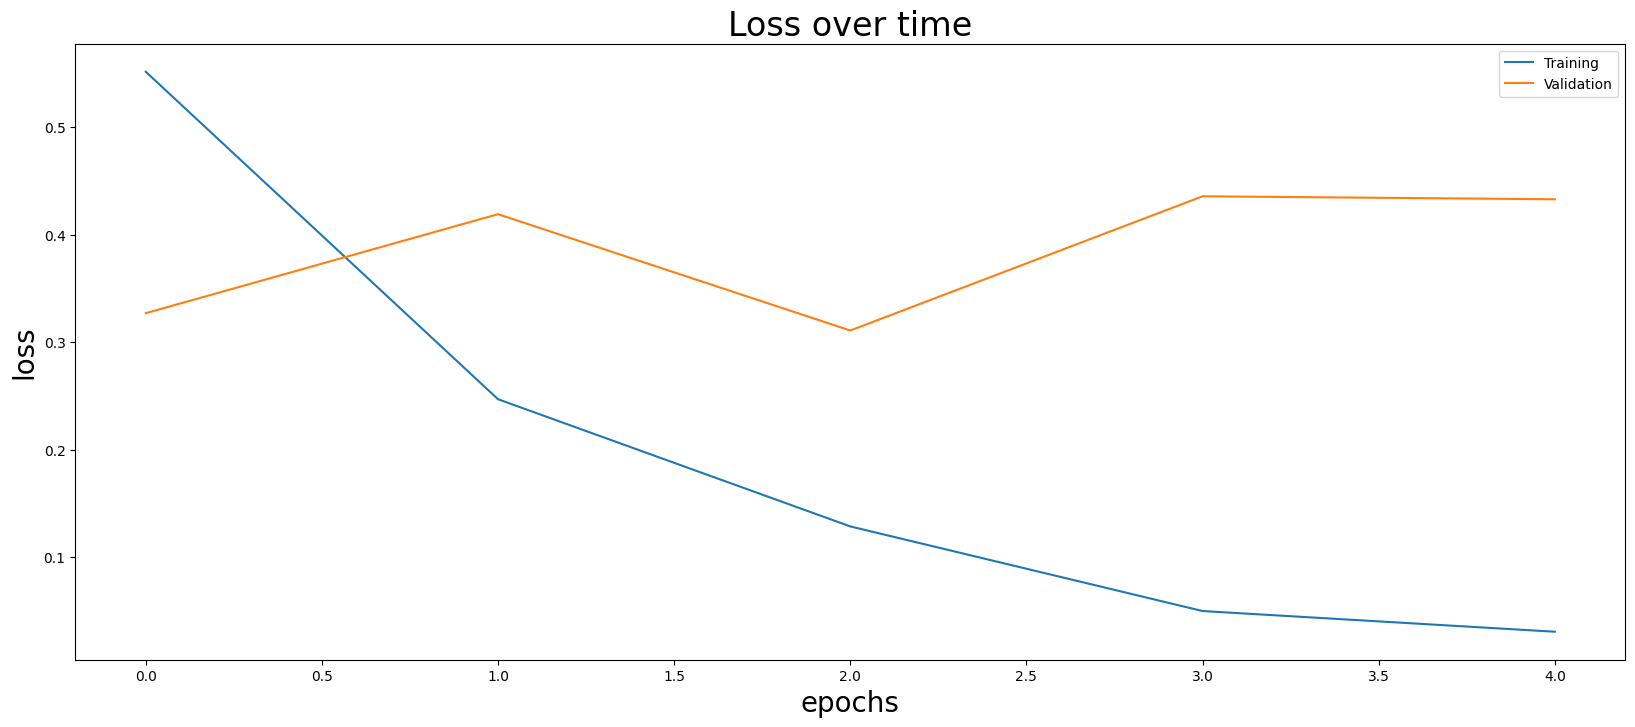

In [21]:
# plt.yscale('log')
plt.ylabel("loss")
plt.xlabel("epochs")
plt.title('Loss over time')

plt.plot(history['loss']);
plt.plot(history['val_loss']);

plt.legend(['Training', 'Validation']);


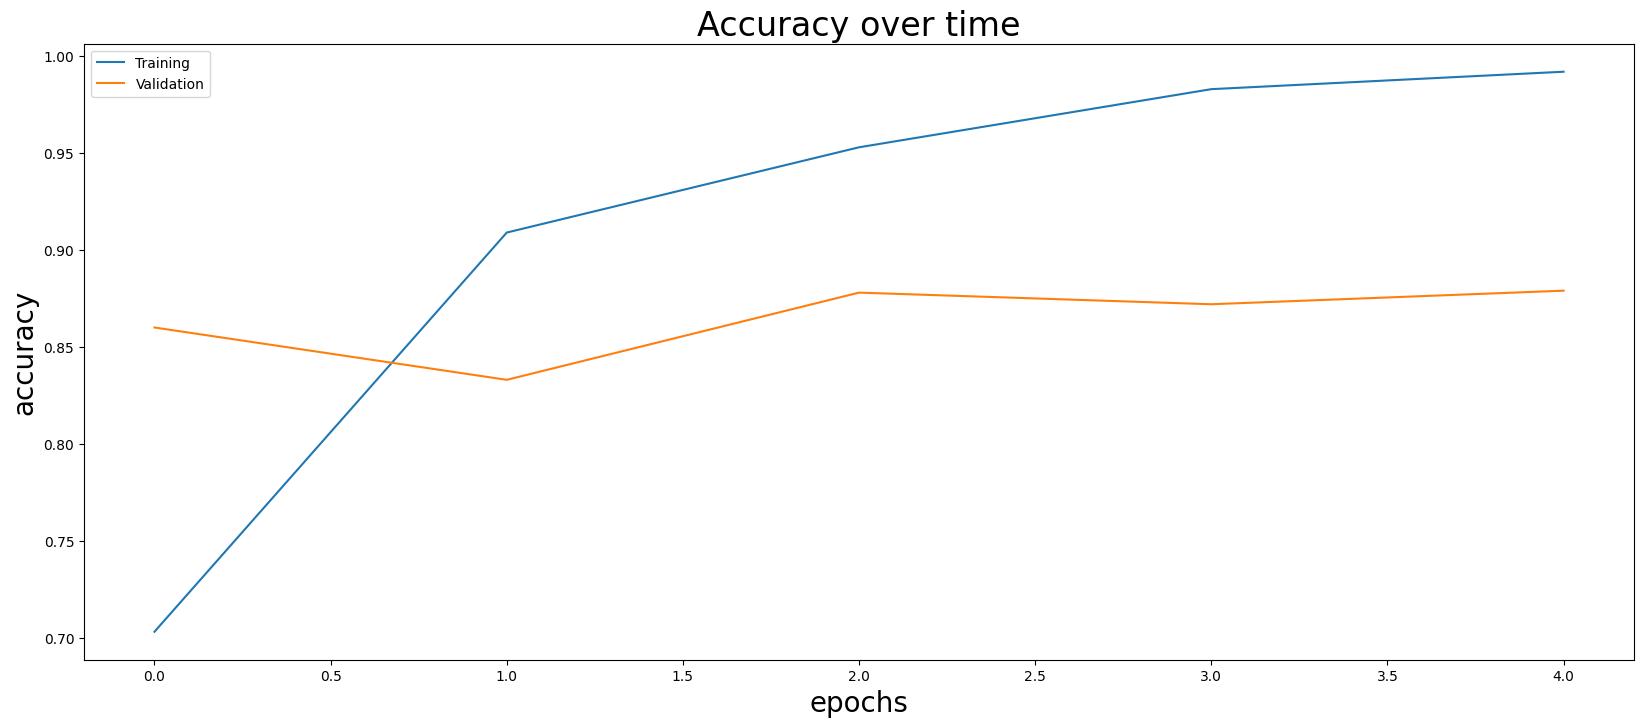

In [22]:
# plt.yscale('log')
plt.ylabel("accuracy")
plt.xlabel("epochs")
plt.title('Accuracy over time')

plt.plot(history['accuracy']);
plt.plot(history['val_accuracy']);

plt.legend(['Training', 'Validation']);


## Anekdotisches ausprobieren

Der Datensatz ist Englisch, also nur englische Beispiele sinnvoll

https://huggingface.co/datasets/imdb
* neg: 0
* pos: 1

https://huggingface.co/transformers/task_summary.html#sequence-classification

In [23]:
movie1 = 'Two small cats seek and find adventures. Nice if you like cute movies.'

In [24]:
movie2 = 'Zombies attack a kindergarden. Splatter!'

In [25]:
movies = [movie1, movie2]

In [26]:
inputs = tokenizer(movies, padding="max_length", truncation=True, return_tensors="pt")
inputs = {key: value.to(device) for key, value in inputs.items()}


In [27]:
# this seems to be a good movie
model.eval()
with torch.no_grad():
    print( torch.softmax(model(**inputs).logits, dim=-1)[0].cpu().numpy())


[0.10525495 0.89474505]


In [28]:
# this one not so much
model.eval()
with torch.no_grad():
    print( torch.softmax(model(**inputs).logits, dim=-1)[1].cpu().numpy())


[0.8123617  0.18763827]


## Modellzusammenfassung ausgeben

In [29]:
from torchinfo import summary

bert_summary = summary(
    model,
    input_data={
        "input_ids": inputs["input_ids"].to(device),
        "attention_mask": inputs["attention_mask"].to(device),
    },
    col_names=("output_size", "num_params", "trainable"),
)

bert_summary

Layer (type:depth-idx)                                  Output Shape              Param #                   Trainable
BertForSequenceClassification                           [2, 2]                    --                        True
├─BertModel: 1-1                                        [2, 768]                  --                        True
│    └─BertEmbeddings: 2-1                              [2, 512, 768]             --                        True
│    │    └─Embedding: 3-1                              [2, 512, 768]             22,268,928                True
│    │    └─Embedding: 3-2                              [2, 512, 768]             1,536                     True
│    │    └─Embedding: 3-3                              [1, 512, 768]             393,216                   True
│    │    └─LayerNorm: 3-4                              [2, 512, 768]             1,536                     True
│    │    └─Dropout: 3-5                                [2, 512, 768]             --       